In [32]:
# Libraries Import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report  

In [33]:
#Load Cleaned Dataset
df=pd.read_csv("cleaned_logistics.csv")
print("Dataset shape:", df.shape) #Expected :(178463, 53)

Dataset shape: (178463, 52)


In [34]:
#Feature Selection and Target Variable
#Target: Late_delivery_risk (0 = On Time, 1 = Late Delivery)
x=df[["Days for shipment (scheduled)", "Benefit per order", "Sales per customer", "Product Price", "Order Item Quantity", "Latitude", "Longitude",
      "Shipping Mode", ]]
x=pd.get_dummies(x, columns=["Shipping Mode"], drop_first=True)
y=df["Late_delivery_risk"]
print(x)

        Days for shipment (scheduled)  Benefit per order  Sales per customer  \
0                                   4          91.250000          314.640015   
1                                   4        -249.089996          311.359985   
2                                   4        -247.779999          309.720001   
3                                   4          22.860001          304.809998   
4                                   4         134.210007          298.250000   
...                               ...                ...                 ...   
178458                              4          40.000000          399.980011   
178459                              2        -613.770019          395.980011   
178460                              4         141.110001          391.980011   
178461                              4         186.229996          387.980011   
178462                              4         168.949997          383.980011   

        Product Price  Order Item Quant

In [35]:
print(y)

0         0
1         1
2         0
3         0
4         0
         ..
178458    0
178459    1
178460    1
178461    0
178462    0
Name: Late_delivery_risk, Length: 178463, dtype: int64


In [36]:
#Split Data into Training 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [37]:
# Model 1 : Random Forest Classifier - To Predict Late Delivery Risk
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train);
print("Model Training Done !")

Model Training Done !


In [38]:
# prediction & Accuracy
y_pred=rfc.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
acc=accuracy_score(y_test,y_pred)
print("the accuracy score of our model is:",acc)

the accuracy score of our model is: 0.676603255540302


In [41]:
clas=classification_report(y_test,y_pred)
print("the classification report of the model is:",clas)

the classification report of the model is:               precision    recall  f1-score   support

           0       0.62      0.72      0.67     16157
           1       0.73      0.64      0.68     19536

    accuracy                           0.68     35693
   macro avg       0.68      0.68      0.68     35693
weighted avg       0.68      0.68      0.68     35693



In [42]:
confusion=confusion_matrix(y_test,y_pred)
print("the confusion matrix of model is \n",confusion)

the confusion matrix of model is 
 [[11633  4524]
 [ 7019 12517]]


In [43]:
print(f" Final Model Accuracy : {acc*100:.2f}%")

 Final Model Accuracy : 67.66%


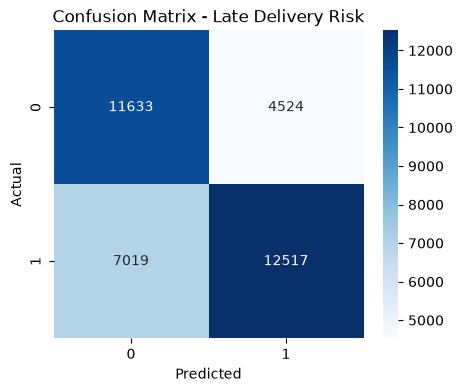

In [44]:
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Late Delivery Risk")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
# Model 2 : Linear Regression for Logistics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [46]:
#Feature and Target for Logistics Model
# Prdicting actual shipping days based on order benefits and sales
x_ls=df[["Days for shipment (scheduled)", "Latitude", "Longitude", "Shipping Mode", "Order Region", "Order Item Quantity"]]
# Convert text columns to numbers
x_ls = pd.get_dummies(x_ls, columns=["Shipping Mode", "Order Region"], drop_first=True)
y_ls=df["Days for shipping (real)"]

In [47]:
print(x_ls)

        Days for shipment (scheduled)   Latitude   Longitude  \
0                                   4  18.251453  -66.037056   
1                                   4  18.279451  -66.037064   
2                                   4  37.292233 -121.881279   
3                                   4  34.125946 -118.291016   
4                                   4  18.253769  -66.037048   
...                               ...        ...         ...   
178458                              4  40.640930  -73.942711   
178459                              2  35.362545 -119.018700   
178460                              4  41.629959  -72.967155   
178461                              4  18.213350  -66.370575   
178462                              4  18.290380  -66.370613   

        Order Item Quantity  Shipping Mode_Same Day  \
0                         1                   False   
1                         1                   False   
2                         1                   False   
3          

In [48]:
print(y_ls)

0         3
1         5
2         4
3         3
4         2
         ..
178458    4
178459    3
178460    5
178461    3
178462    4
Name: Days for shipping (real), Length: 178463, dtype: int64


In [49]:
# Train Test Split
x_ls_train, x_ls_test, y_ls_train, y_ls_test = train_test_split(x_ls, y_ls, test_size=0.2, random_state=42)

In [50]:
#Model Training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_ls_train, y_ls_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 0.79,-0. , 0. ,..., 0.1 , 0.09, 0.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['Days for shipment (scheduled)','Latitude','Longitude',..., 'Order Region_West Asia','Order Region_West of USA ', 'Order Region_Western Europe']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.105
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [51]:
y_ls_pred = lr.predict(x_ls_test)

In [52]:
print(y_ls_pred)

[3.98657001 3.98076563 3.98919749 ... 3.98160988 3.97700811 3.98570062]


In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [54]:
r2=r2_score(y_ls_test, y_ls_pred)
print(f"R2 Score: {r2:.4f}")

R2 Score: 0.3902


In [55]:
mae = mean_absolute_error(y_ls_test, y_ls_pred)
print(f"MAE : {mae:.4f} Days")

MAE : 0.9869 Days


In [56]:
mse = mean_squared_error(y_ls_test, y_ls_pred)
print(f"MSE : {mse:.4f}")


MSE : 1.6071
